# 2 april: TOZ differentiaalvergelijkingen met SymPy

Gegeven is de volgende constructie:

```{figure-start} ./opgave2_data/constructie.svg
:align: center
:source: https://github.com/Structural-Mechanics-CEG/mechanics-figures-source/tree/main/sympy_5
:number:
```

$$EI\left(x\right) = 4000 \cdot e^{-\cfrac{x}{3}}$$

```{figure-end}
```

Vind de maximale waarde van het moment en de verplaatsing op $x=3$ en $x=3.3$. Maak de opdracht in [WebLab](https://weblab.tudelft.nl/ctb1310/2025-2026/assignment/166889/info). Heb je nog geen toegang? Schrijf je dan eerst [hier](https://weblab.tudelft.nl/ctb1310/2025-2026/enroll) in voor dit vak op WebLab.

::::{question} Opgave
:type: short-answer
:variant: blocks
:admonition:
:class: exercise
:nocaption:

Wat is het maximale moment in $\rm{kNm}$?
---
M[67.5]
---

::::

::::{question} Opgave
:type: short-answer
:variant: blocks
:admonition:
:class: exercise
:nocaption:

---
MRP[182.607;0.025] Wat is de verplaatsing op $x=3$ in $\rm{mm}$?
MRP[185.476;0.025] Wat is de verplaatsing op $x=3.3$ in $\rm{mm}$?
---

::::

::::{admonition-start} Uitwerking
:class: solution, dropdown
::::

In [140]:
import sympy as sym
sym.init_printing(use_latex='mathjax')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display, Math

%config InlineBackend.figure_formats = ['svg']

def display(*objs):
    for obj in objs:
        if isinstance(obj, dict):
            lines = [f"{sym.latex(k)} &= {sym.latex(obj[k])}" for k in sorted(obj, key=lambda s: str(s))]
            ipy_display(Math(r"\begin{aligned}" + r"\\ ".join(lines) + r"\end{aligned}"))
        else:
            ipy_display(obj)

def plot(w_list, x_range_list,ylabel):
    fig = plt.figure(facecolor='none')
    for i, w in enumerate(w_list):
        # check if x is the only symbol in the expression
        if len(w.free_symbols) > 1:
            raise ValueError('The expression must be a function of x only.')
        
        w_numpy = sym.lambdify(x, w)
        x_vals = np.linspace(x_range_list[i][0], x_range_list[i][1], 100)
        
        # if the expression is a constant, we need to make sure that it is broadcasted correctly
        if isinstance(w_numpy(x_vals),float) or isinstance(w_numpy(x_vals),int):
            w_numpy = np.vectorize(w_numpy)
            plt.plot([x_range_list[i][0], x_range_list[i][1]],[w_numpy(x_vals),w_numpy(x_vals)])
        else:
            plt.plot(x_vals,w_numpy(x_vals))

        plt.xlabel('$x$')
        plt.ylabel(ylabel)
    ax = plt.gca()
    ax.set_facecolor('none')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.invert_yaxis()

In [173]:
import sympy as sym

In [174]:
sym.var('x')
sym.var('C1, C2, C3, C4');

In [175]:
EI = sym.exp(-x/3)*4000
q1 = 15

In [176]:
V1 = sym.integrate(-q1,x)+C1
M1 = sym.integrate(V1,x)+C2
kappa1 = M1 / EI
phi1 = sym.integrate(kappa1,x)+C3
w1 = sym.integrate(-phi1,x)+C4

In [178]:
Eq1  = sym.Eq(  w1.subs(x, 0), 0)
Eq2  = sym.Eq(  M1.subs(x, 0), 0)
Eq3  = sym.Eq(  w1.subs(x, 6), 0)
Eq4  = sym.Eq(  M1.subs(x, 6), 0)

In [179]:
sol = sym.solve((Eq1, Eq2, Eq3, Eq4), (C1, C2, C3, C4))
display(sol)

<IPython.core.display.Math object>

In [ ]:
w1_oplossing = w1.subs(sol)
phi1_oplossing = phi1.subs(sol)
M1_oplossing = M1.subs(sol)

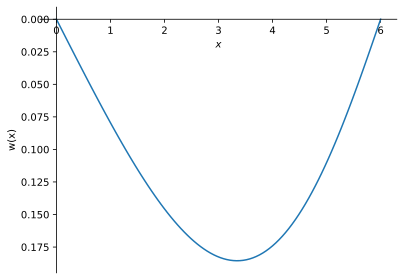

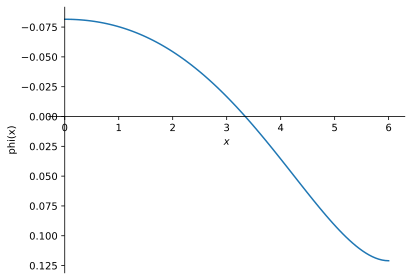

In [182]:
plot([w1_oplossing], [(0, 6)], 'w(x)')
plot([phi1_oplossing], [(0, 6)], 'phi(x)')

In [184]:
M1_3 = M1_oplossing.subs(x,3) # kNm
display(M1_3)
display(M1_3.evalf())

135/2

67.5000000000000

In [ ]:
w1_3 = w1_oplossing.subs(x,3)*1000 # mm
w1_right_of_3 = w1_oplossing.subs(x,3.3)*1000 #mm

display(w1_3)
display(w1_3.evalf())
display(w1_right_of_3)
display(w1_right_of_3.evalf())

        2                
  1215⋅ℯ    6075   6075⋅ℯ
- ─────── - ──── + ──────
     8       8       8   

182.607368460995

                             2
1419.91056562844 - 167.0625⋅ℯ 

185.476381100843

::::{admonition-end}
::::